Automated Trading Systems and Artificial Intelligence

In [1]:
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')


In [2]:
cp= pd.read_csv('btcusd.csv')

In [3]:
cp.head()

,timestamp,open,high,low,close,volume
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419


In [4]:
cp.shape

(350, 6)

In [5]:
cp.info()
cp.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  350 non-null    object 
 1   open       350 non-null    float64
 2   high       350 non-null    float64
 3   low        350 non-null    float64
 4   close      350 non-null    float64
 5   volume     350 non-null    float64
dtypes: float64(5), object(1)
memory usage: 16.5+ KB


Index(['timestamp', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [6]:
import datetime as dt
from datetime import datetime
cp['timestamp'] = pd.to_datetime(cp['timestamp'])
cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  350 non-null    datetime64[ns]
 1   open       350 non-null    float64       
 2   high       350 non-null    float64       
 3   low        350 non-null    float64       
 4   close      350 non-null    float64       
 5   volume     350 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 16.5 KB


In [7]:
cp.head()

,timestamp,open,high,low,close,volume
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419


## Adding technical Indicators (RSA & SMI)

In [8]:

from finta import TA

In [9]:
ohlcv=cp[['open','high','low','close','volume']]
ohlcv.head()

,open,high,low,close,volume
0,67346.15,67373.06,67060.30,67073.08,120.458109
1,69014.87,69498.00,66802.00,67346.15,10226.593467
2,68363.73,69380.00,68083.18,69014.86,2632.892149
3,68426.11,68689.29,68005.83,68363.73,1868.869588
4,67399.86,69000.62,67149.24,68426.11,11802.744419


In [10]:
cp['SMA']=TA.SMA(ohlcv, 42)
cp['RSI']=TA.RSI(ohlcv)
cp.tail()

,timestamp,open,high,low,close,volume,SMA,RSI
345,2023-11-12,37139.94,37247.00,36740.90,37086.03,3317.502786,40065.868333,44.410541
346,2023-11-11,37324.84,37424.03,36701.50,37139.12,5344.453828,39909.029524,44.682801
347,2023-11-10,36704.01,37548.80,36334.46,37324.83,15183.168535,39749.770000,45.684922
348,2023-11-09,35639.13,37999.00,35555.16,36706.59,29045.851956,39579.085952,42.898731
349,2023-11-08,35416.63,36113.59,35103.14,35639.13,12253.158085,39387.761190,38.529451


In [11]:
cp.rename(columns={'timestamp': 'date'}, inplace=True)
cp.head()


,date,open,high,low,close,volume,SMA,RSI
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,NaN,NaN
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,NaN,100.000000
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,NaN,100.000000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,NaN,73.271619
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,NaN,73.988907


In [12]:
# Fill missing values with the median
cp['SMA'].fillna(cp['SMA'].median(), inplace=True)
cp['RSI'].fillna(cp['RSI'].median(), inplace=True)
cp

,date,open,high,low,close,volume,SMA,RSI
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,61904.077619,47.078523
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,61904.077619,100.000000
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,61904.077619,100.000000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,61904.077619,73.271619
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,61904.077619,73.988907
...,...,...,...,...,...,...,...,...
345,2023-11-12,37139.94,37247.00,36740.90,37086.03,3317.502786,40065.868333,44.410541
346,2023-11-11,37324.84,37424.03,36701.50,37139.12,5344.453828,39909.029524,44.682801
347,2023-11-10,36704.01,37548.80,36334.46,37324.83,15183.168535,39749.770000,45.684922
348,2023-11-09,35639.13,37999.00,35555.16,36706.59,29045.851956,39579.085952,42.898731


In [13]:

import matplotlib.pyplot as plt


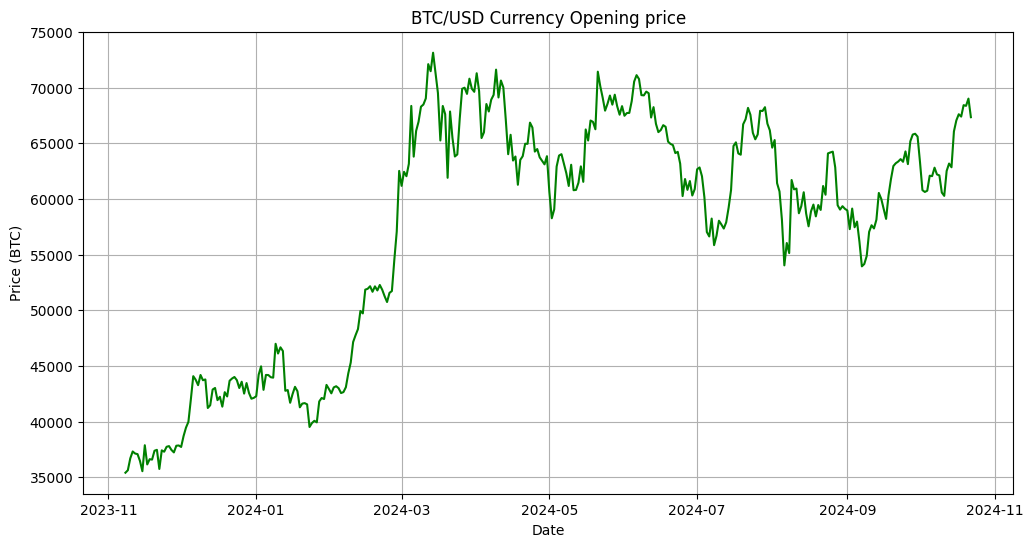

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(cp['date'],cp['open'],'g')
plt.title("BTC/USD Currency Opening price")
plt.xlabel("Date")
plt.ylabel("Price (BTC)")
plt.grid(True)
plt.show() 

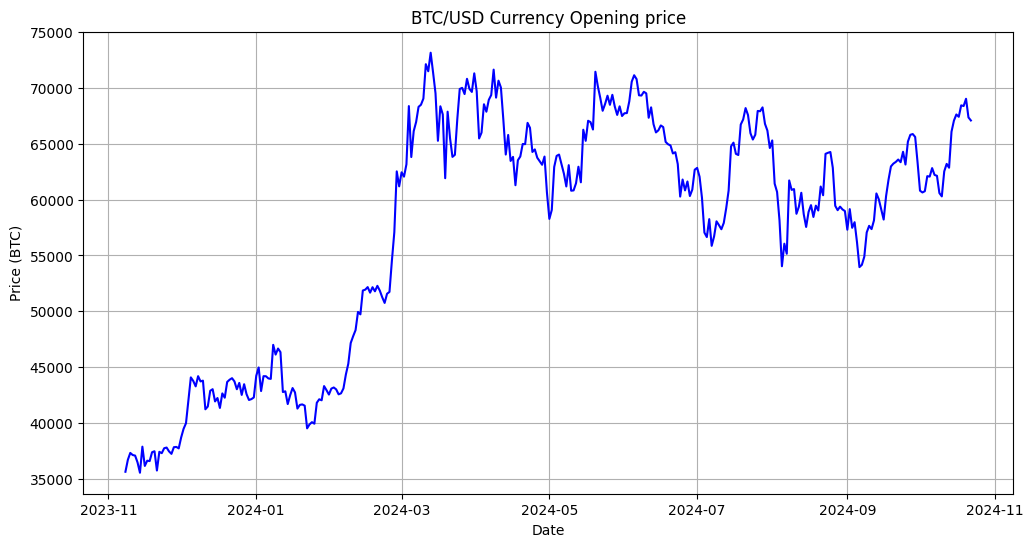

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(cp['date'],cp['close'],'b')
plt.title("BTC/USD Currency Opening price")
plt.xlabel("Date")
plt.ylabel("Price (BTC)")
plt.grid(True)
plt.show() 

In [16]:
cp.corr()

,date,open,high,low,close,volume,SMA,RSI
date,1.000000,0.694162,0.689380,0.702625,0.691908,-0.268540,0.631496,0.231300
open,0.694162,1.000000,0.994598,0.992652,0.988857,-0.046452,0.870821,0.548233
high,0.689380,0.994598,1.000000,0.991204,0.995993,-0.007687,0.878047,0.550754
low,0.702625,0.992652,0.991204,1.000000,0.994231,-0.116268,0.871360,0.556634
close,0.691908,0.988857,0.995993,0.994231,1.000000,-0.051639,0.878270,0.558233
volume,-0.268540,-0.046452,-0.007687,-0.116268,-0.051639,1.000000,-0.022674,-0.018235
SMA,0.631496,0.870821,0.878047,0.871360,0.878270,-0.022674,1.000000,0.187959
RSI,0.231300,0.548233,0.550754,0.556634,0.558233,-0.018235,0.187959,1.000000


<Axes: >

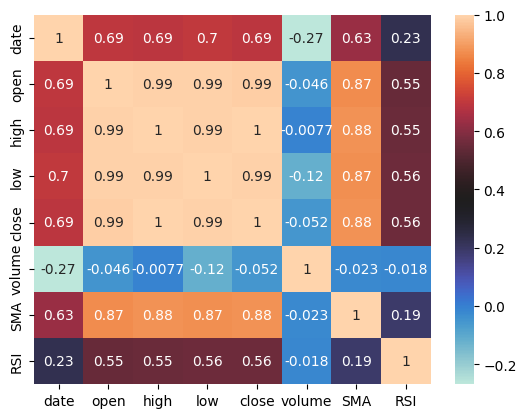

In [17]:
import seaborn as sns
sns.heatmap(cp.corr(), annot=True, cmap='icefire')

In [18]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


In [19]:
cp

,date,open,high,low,close,volume,SMA,RSI
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,61904.077619,47.078523
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,61904.077619,100.000000
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,61904.077619,100.000000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,61904.077619,73.271619
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,61904.077619,73.988907
...,...,...,...,...,...,...,...,...
345,2023-11-12,37139.94,37247.00,36740.90,37086.03,3317.502786,40065.868333,44.410541
346,2023-11-11,37324.84,37424.03,36701.50,37139.12,5344.453828,39909.029524,44.682801
347,2023-11-10,36704.01,37548.80,36334.46,37324.83,15183.168535,39749.770000,45.684922
348,2023-11-09,35639.13,37999.00,35555.16,36706.59,29045.851956,39579.085952,42.898731


# Sentiment Analysis

### Collecting Btc news from NewsApi

In [20]:
from newsapi import NewsApiClient

In [21]:
newsapi = NewsApiClient(api_key='c247aced72954b3e909d99b0c0bab8b6')

In [22]:
news_data = newsapi.get_everything(q='btc', from_param='2023-18-11', to='2024-22-10',language='en', sort_by='relevancy')

In [23]:
# Extract headlines
headlines = [article['title'] for article in news_data['articles']]


### Using Vadersentiment to analyize sentiment

In [24]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [25]:
# Initialize the sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Analyze the sentiment of each headline
sentiments = [analyzer.polarity_scores(headline)['compound'] for headline in headlines]


In [26]:
# Convert into a DataFrame
import pandas as pd
news_sentiment_df = pd.DataFrame({
    'headline': headlines,
    'sentiment': sentiments
})


In [27]:
news_sentiment_df.head()

,headline,sentiment
0,"MicroStrategy Buys 1,070 BTC, Plans to Raise U...",0.0000
1,El Salvador Strikes $1.4 Billion IMF Deal Afte...,-0.3612
2,Core Scientific finds a balance in bitcoin min...,0.0000
3,Crypto surge: Key players reveal their strategies,0.0000
4,"The Random Show — 2025 Predictions (AI, Aliens...",0.5859


In [28]:
cp.drop(cp.tail(10).index, inplace=True)

In [29]:
cp.tail()

,date,open,high,low,close,volume,SMA,RSI
335,2023-11-22,35755.33,37875.00,35633.00,37424.31,17606.972395,41586.480238,33.255610
336,2023-11-21,37472.76,37675.77,35744.90,35751.89,20837.739343,41366.934762,27.397369
337,2023-11-20,37389.06,37784.07,36720.00,37475.64,14114.010399,41206.336190,39.271651
338,2023-11-19,36596.14,37546.62,36404.52,37391.19,4366.448923,41089.744048,38.935672
339,2023-11-18,36631.56,36857.15,36205.89,36594.89,3468.398214,40957.693095,35.823501


In [30]:
cp.head()

,date,open,high,low,close,volume,SMA,RSI
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,61904.077619,47.078523
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,61904.077619,100.000000
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,61904.077619,100.000000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,61904.077619,73.271619
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,61904.077619,73.988907


## Merging sentiment score and historical data based on date

In [31]:

news_sentiment_df['date'] =(cp['date'])


In [32]:
# Merge the price data with the sentiment data based on date
combined_df = pd.merge(cp, news_sentiment_df, on='date', how='left')

# Fill missing sentiment data with neutral (0) sentiment
combined_df['sentiment'].fillna(0, inplace=True)

In [33]:
combined_df.head()

,date,open,high,low,close,volume,SMA,RSI,headline,sentiment
0,2024-10-22,67346.15,67373.06,67060.30,67073.08,120.458109,61904.077619,47.078523,"MicroStrategy Buys 1,070 BTC, Plans to Raise U...",0.0000
1,2024-10-21,69014.87,69498.00,66802.00,67346.15,10226.593467,61904.077619,100.000000,El Salvador Strikes $1.4 Billion IMF Deal Afte...,-0.3612
2,2024-10-20,68363.73,69380.00,68083.18,69014.86,2632.892149,61904.077619,100.000000,Core Scientific finds a balance in bitcoin min...,0.0000
3,2024-10-19,68426.11,68689.29,68005.83,68363.73,1868.869588,61904.077619,73.271619,Crypto surge: Key players reveal their strategies,0.0000
4,2024-10-18,67399.86,69000.62,67149.24,68426.11,11802.744419,61904.077619,73.988907,"The Random Show — 2025 Predictions (AI, Aliens...",0.5859


In [34]:
combined_df.shape[0]

340

In [35]:
combined_df.tail()

,date,open,high,low,close,volume,SMA,RSI,headline,sentiment
335,2023-11-22,35755.33,37875.00,35633.00,37424.31,17606.972395,41586.480238,33.255610,NaN,0.0
336,2023-11-21,37472.76,37675.77,35744.90,35751.89,20837.739343,41366.934762,27.397369,NaN,0.0
337,2023-11-20,37389.06,37784.07,36720.00,37475.64,14114.010399,41206.336190,39.271651,NaN,0.0
338,2023-11-19,36596.14,37546.62,36404.52,37391.19,4366.448923,41089.744048,38.935672,NaN,0.0
339,2023-11-18,36631.56,36857.15,36205.89,36594.89,3468.398214,40957.693095,35.823501,NaN,0.0


## Scaling the features

In [36]:

from sklearn.preprocessing import MinMaxScaler
import numpy as np


In [37]:
combined_df['date_ordinal'] = combined_df['date'].apply(lambda x: x.toordinal())
combined_df['day_sin'] = np.sin(2 * np.pi * combined_df['date_ordinal'] / 365)
combined_df['day_cos'] = np.cos(2 * np.pi * combined_df['date_ordinal'] / 365)

In [38]:
features = ['close','open','high','low','volume','SMA','RSI','sentiment','day_sin','day_cos']

In [87]:
#Normalize the features
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(combined_df[features])
scaled_data


array([[0.83784245, 0.84513283, 0.82523564, ..., 0.47468863, 0.91074208,
        0.78511717],
       [0.84514708, 0.88977523, 0.88269996, ..., 0.23282443, 0.90577329,
        0.79214524],
       [0.8897851 , 0.87235562, 0.87950891, ..., 0.47468863, 0.90068425,
        0.79908674],
       ...,
       [0.04611035, 0.04370633, 0.02506651, ..., 0.47468863, 0.9961157 ,
        0.56223152],
       [0.04385131, 0.02249375, 0.0186452 , ..., 0.47468863, 0.99497083,
        0.5707622 ],
       [0.02255027, 0.02344133, 0.        , ..., 0.47468863, 0.99367929,
        0.5792719 ]])

## LSTM Model

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import LSTM, Dense

In [121]:
# Prepare the data for LSTM
def create_dataset(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :-1])
        y.append(data[i + look_back, 0])  # Predicting the 'Close' price
    return np.array(X), np.array(y)

look_back = 100
data_values = combined_df[features].values
X, y = create_dataset(data_values, look_back)

# Split the data into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape data to [samples, timesteps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(features) - 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], len(features) - 1))

In [98]:
X_train.shape[0]

192

In [91]:
X_test

array([[[ 6.40247700e+04,  6.71486200e+04,  6.91000000e+04, ...,
          5.00278192e+01,  0.00000000e+00, -7.17676914e-01],
        [ 6.71486100e+04,  7.00207100e+04,  7.12657400e+04, ...,
          5.76790135e+01,  0.00000000e+00, -7.05583610e-01],
        [ 7.00207300e+04,  7.06384000e+04,  7.13058600e+04, ...,
          6.32502745e+01,  0.00000000e+00, -6.93281227e-01],
        ...,
        [ 4.39502800e+04,  4.39927900e+04,  4.45100100e+04, ...,
          4.84848268e+01,  0.00000000e+00,  7.63888613e-01],
        [ 4.39924400e+04,  4.41877600e+04,  4.42609500e+04, ...,
          4.86523135e+01,  0.00000000e+00,  7.74884041e-01],
        [ 4.41865900e+04,  4.41983500e+04,  4.44433700e+04, ...,
          4.94670944e+01,  0.00000000e+00,  7.85649855e-01]],

       [[ 6.71486100e+04,  7.00207100e+04,  7.12657400e+04, ...,
          5.76790135e+01,  0.00000000e+00, -7.05583610e-01],
        [ 7.00207300e+04,  7.06384000e+04,  7.13058600e+04, ...,
          6.32502745e+01,  0.00000000e

In [116]:
len(features)-9

1

In [111]:
X_train.shape[1], 1

(100, 1)

In [102]:
print(X_train.shape)
print(X_test.shape)

(192, 100, 9)
(48, 100, 9)


In [103]:
print(y_train.shape)
print(y_test.shape)

(192,)
(48,)


In [79]:
y_train

array([60808.42, 59224.58, 57909.03, 57340.77, 57712.59, 58047.86,
       56699.43, 55854.09, 58244.75, 56639.43, 57042.14, 60145.01,
       62040.22, 62830.13, 62668.26, 60885.67, 60313.35, 61615.39,
       60816.68, 61789.71, 60263.  , 63171.43, 64235.01, 64120.28,
       64840.88, 64943.79, 65152.8 , 66481.81, 66628.75, 66192.  ,
       66004.39, 66738.85, 68248.6 , 67316.53, 69497.73, 69637.87,
       69304.05, 69324.53, 70773.64, 71121.11, 70542.32, 68791.  ,
       67735.52, 67719.29, 67472.41, 68338.58, 67569.45, 68321.98,
       69368.72, 68473.72, 69289.67, 68547.8 , 67940.45, 69109.93,
       70142.84, 71432.17, 66261.62, 66923.87, 67046.33, 65252.18,
       66244.69, 61539.84, 62932.37, 61453.02, 60814.63, 60787.47,
       63073.57, 61169.53, 62315.76, 63162.24, 64023.45, 63902.88,
       62913.03, 59071.89, 58265.59, 60622.1 , 63844.85, 63108.94,
       63422.  , 63742.39, 64484.44, 64255.78, 66414.16, 66859.17,
       64952.92, 64968.87, 63848.37, 63513.85, 61279.36, 63814

In [104]:
# Build the LSTM model
model = Sequential()

#First Layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

#Second Layer
model.add(LSTM(units=60, return_sequences=True))
model.add(Dropout(0.3))

#Third Layer
model.add(LSTM(units=80, return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units=100, return_sequences=False))
model.add(Dropout(0.5))

model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')




In [105]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 100, 50)        │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 100)            │        72,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,261 (610.39 KB)

 Trainable params: 156,261 (610.39 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test))



Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 70s 5s/step - loss: 3736363520.0000 - val_loss: 1710136320.0000
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 3680076800.0000 - val_loss: 1709930496.0000
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 3672840448.0000 - val_loss: 1709766272.0000
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 3719316480.0000 - val_loss: 1709630848.0000
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 3632930560.0000 - val_loss: 1709510016.0000
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 3671626496.0000 - val_loss: 1709403008.0000
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 3695787264.0000 - val_loss: 1709309312.0000
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 3629722112.0000 - val_loss: 1709231232.0000
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 3696463872.0000 - val_loss: 1709169280.0000
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 3749463040.0000 - val_loss: 1709119104.0000
Epoch 1

In [86]:
past_100_days = combined_df[features].tail(100)
past_100_days

,close,open,high,low,volume,SMA,RSI,sentiment,day_sin,day_cos
240,51731.00,51568.63,51967.82,51275.01,3617.401068,66479.677143,29.369555,0.0,0.025818,-0.999667
241,51570.65,50746.98,51696.19,50576.55,3448.965768,66066.600000,29.209198,0.0,0.043022,-0.999074
242,50747.05,51260.29,51512.68,50513.01,11679.166258,65659.231905,28.352909,0.0,0.060213,-0.998186
243,51258.70,51851.46,52076.00,50905.65,13104.514081,65248.124048,29.731087,0.0,0.077386,-0.997001
244,51851.67,52277.53,52394.91,50628.60,13735.034072,64911.546667,31.378533,0.0,0.094537,-0.995521
...,...,...,...,...,...,...,...,...,...,...
335,37424.31,35755.33,37875.00,35633.00,17606.972395,41586.480238,33.255610,0.0,0.995919,0.090252
336,35751.89,37472.76,37675.77,35744.90,20837.739343,41366.934762,27.397369,0.0,0.994218,0.107381
337,37475.64,37389.06,37784.07,36720.00,14114.010399,41206.336190,39.271651,0.0,0.992222,0.124479
338,37391.19,36596.14,37546.62,36404.52,4366.448923,41089.744048,38.935672,0.0,0.989932,0.141540


In [117]:
# Predict future prices
predicted_price = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step


In [118]:
predicted_price=scaler.inverse_transform(predicted_price)
predicted_price

ValueError: non-broadcastable output operand with shape (48,1) doesn't match the broadcast shape (48,10)

In [119]:
predicted_price

array([[27.778591],
       [27.778591],
       [27.778582],
       [27.778582],
       [27.778591],
       [27.778595],
       [27.778595],
       [27.778591],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.77859 ],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778591],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778591],
       [27.778591],
       [27.778591],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778595],
       [27.778593],
       [27.778595],
       [27.778595]], dtype=float32)

In [52]:
y_test

array([46995.1 , 43950.28, 43992.44, 44186.59, 44193.29, 42862.44,
       44972.8 , 44220.78, 42288.06, 42141.03, 42063.45, 42581.23,
       43474.4 , 42515.53, 43589.67, 43025.03, 43726.35, 44013.73,
       43875.32, 43674.77, 42266.22, 42650.01, 41349.59, 42237.29,
       41933.89, 43027.77, 42885.54, 41477.39, 41229.61, 43793.68,
       43723.25, 44192.87, 43280.95, 43764.05, 44084.39, 41987.24,
       39984.81, 39478.95, 38703.54, 37732.27, 37863.84, 37838.26,
       37241.63, 37462.79, 37805.99, 37745.84, 37304.05, 37424.31,
       35751.89, 37475.64, 37391.19, 36594.89])

In [68]:
scaler.scale_

array([2.67500197e-05, 2.67524815e-05, 2.70427996e-05, 2.80078310e-05,
       1.52777563e-05, 3.66830828e-05, 1.18370880e-02, 6.69612964e-01,
       5.00004630e-01, 5.00009260e-01])

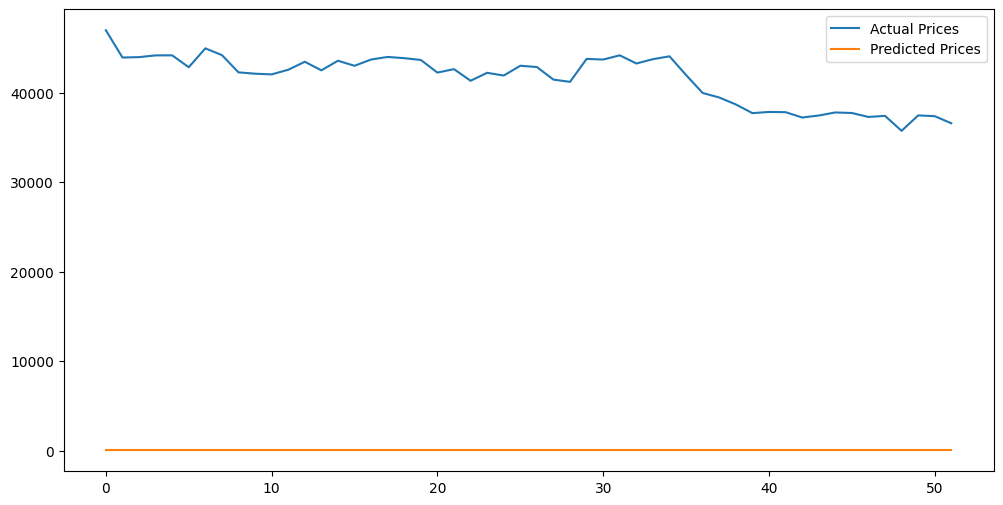

In [53]:
# Visualize the results
import matplotlib.pyplot as plt
plt.figure(figsize = (12,6))
plt.plot(y_test, label='Actual Prices')
plt.plot(predicted_price, label='Predicted Prices')
plt.legend()
plt.show()

In [54]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predicted_price)
mae_percentage = (mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))

Mean absolute error on test set: 99.92%


In [55]:
from sklearn.metrics import r2_score

# Actual values
actual = y_test

# Predicted values
predicted =predicted_price

# Calculate the R2 score
r2 = r2_score(actual, predicted)

print("R2 score:", r2)

R2 score: -226.70614909906666


## BACKTESTING


In [56]:
from ibapi.client import EClient
from ibapi.wrapper import EWrapper
from ibapi.contract import Contract
import time

In [57]:
class IBApi(EWrapper, EClient):
    def __init__(self):
        EClient.__init__(self, self)
        self.data = []
        self.current_date = None

    def nextValidId(self, orderId):
        self.start()

    def historicalData(self, reqId, bar):
        self.data.append([bar.date, bar.open, bar.high, bar.low, bar.close, bar.volume])
        self.current_date = bar.date

    def start(self):
        contract = Contract()
        contract.symbol = 'BTC'
        contract.secType = 'CRYPTO'
        contract.exchange = 'PAXOS'
        contract.currency = 'USD'
        self.reqHistoricalData(1, contract, '', '1 Y', '1 day', 'MIDPOINT', 0, 1, False, [])
# Initialize IB API
api = IBApi()
api.connect('127.0.0.1', 7497, 0)

# Run the API to get historical data
api.run()

ERROR -1 502 Couldn't connect to TWS. Confirm that "Enable ActiveX and Socket EClients" 
is enabled and connection port is the same as "Socket Port" on the 
TWS "Edit->Global Configuration...->API->Settings" menu. Live Trading ports: 
TWS: 7496; IB Gateway: 4001. Simulated Trading ports for new installations 
of version 954.1 or newer:  TWS: 7497; IB Gateway: 4002


In [58]:
# Backtest with real-time data
def backtest(api, model, scaler, look_back=60):
    while True:
        if api.current_date != api.data[-1][0]:
            # Fetch new data
            new_data = np.array(api.data[-look_back:])[:, 1:].astype(float)
            new_data_scaled = scaler.transform(new_data)

            # Prepare data for prediction
            X_new = np.array([new_data_scaled])
            X_new = np.reshape(X_new, (X_new.shape[0], X_new.shape[1], X_new.shape[2]))

            # Make prediction
            prediction = model.predict(X_new)
            prediction = scaler.inverse_transform(np.concatenate((new_data[:-1], prediction), axis=1))[:, -1][-1]

            # Print the prediction
            print(f"Predicted Close Price: {prediction}")

            # Wait before fetching new data
            time.sleep(86400)  # 1 day in seconds

# Start backtesting
backtest(api, model, scaler)

IndexError: list index out of range